# WC 2022 Trajectory Prediction — Amazon Chronos (zero-shot)

**Источник данных:** [PFF FC Open Tracking Data](https://www.blog.fc.pff.com/blog/pff-fc-release-2022-world-cup-data) — broadcast tracking (**~30 fps**) для всех 64 матчей FIFA World Cup 2022.

Матч: **Senegal vs Netherlands** (game id `3812`, 2022-11-21, группа H)

Файлы (лежат рядом с ноутбуком):
- `3812_tracking.jsonl` — трекинговые данные кадр за кадром (~185 k строк)
- `3812_meta.json` — метаданные матча (команды, тайминги, FPS, размер поля)
- `3812_rosters.json` — информация о командах

**Pipeline:**
1. Загрузка метаданных и построение маппинга номер → имя игрока из поля `game_event`
2. Парсинг `tracking.jsonl` с даунсэмплингом до **~5 fps** (каждый 6-й кадр)
3. Конвертация координат: метры от центра поля → абсолютные [0,105]×[0,68] м
4. **Chronos** zero-shot: предсказание x, y независимо (K=5 сэмплов)
5. Метрики: ADE, FDE, **minADE@K**, **minFDE@K** через **TimeSeriesSplit** (без утечки)
6. Визуализация траектории на поле (pitch 105×68 м)
7. **Optuna** тюнинг `context_len` + `pred_len` → сравнение и ре-визуализация

In [ ]:
import warnings; warnings.filterwarnings('ignore')
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
from chronos import ChronosPipeline
from sklearn.model_selection import TimeSeriesSplit
from mplsoccer import Pitch

# ── constants ──────────────────────────────────────────────
GAME_ID       = "3812"                        # Senegal vs Netherlands, 2022-11-21
META_PATH     = Path(f"{GAME_ID}_meta.json")
ROSTERS_PATH  = Path(f"{GAME_ID}_rosters.json")
TRACK_PATH    = Path(f"{GAME_ID}_tracking.jsonl")

# Поле: 105m × 68m, координаты в метрах от центра → конвертируем в [0,105]×[0,68]
PITCH_LEN, PITCH_WID = 105.0, 68.0
RAW_FPS       = 30             # fps исходных данных
SAMPLE_EVERY  = 6              # брать каждый 6-й кадр → 5 fps
SAMPLE_RATE   = RAW_FPS / SAMPLE_EVERY   # ~5 fps

K             = 5              # число сэмплов траектории
DEFAULT_CTX   = 64             # длина контекста в кадрах (~12.8 сек @ 5fps)
DEFAULT_PRED  = 16             # горизонт предсказания (~3.2 сек @ 5fps)
N_SPLITS      = 3

DEVICE = ("mps"  if torch.backends.mps.is_available() else
          "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Sample rate: {SAMPLE_RATE:.2f} fps  "
      f"(ctx={DEFAULT_CTX} кадров = {DEFAULT_CTX/SAMPLE_RATE:.1f} с, "
      f"pred={DEFAULT_PRED} кадров = {DEFAULT_PRED/SAMPLE_RATE:.1f} с)")

Device: mps
Sample rate: 5.00 fps  (ctx=64 кадров = 12.8 с, pred=16 кадров = 3.2 с)


In [ ]:
# 1. Загрузка метаданных и маппинг jersey_number → имя игрока
meta = json.load(META_PATH.open())[0]
home_team = meta['homeTeam']['name']   # "Senegal"
away_team = meta['awayTeam']['name']   # "Netherlands"
print(f"Match: {home_team} vs {away_team}  (id={meta['id']})")
print(f"FPS: {meta['fps']}  |  Pitch: {meta['stadium']['pitches'][0]['length']}m × {meta['stadium']['pitches'][0]['width']}m")

# Сканируем tracking файл один раз для маппинга номер+команда → имя
jersey_to_name: dict[tuple, str] = {}
with TRACK_PATH.open() as f:
    for line in f:
        ge = json.loads(line).get('game_event')
        if ge and ge.get('player_name') and ge.get('shirt_number') and ge.get('team_name'):
            key = (ge['team_name'], str(ge['shirt_number']))
            jersey_to_name[key] = ge['player_name']

print(f"\nИгроки найдены ({len(jersey_to_name)}):")
for (team, num), name in sorted(jersey_to_name.items()):
    print(f"  {team} #{num:<3} {name}")

Match: Senegal vs Netherlands  (id=3812)
FPS: 29.97  |  Pitch: 105.0m × 68.0m

Игроки найдены (29):
  Netherlands #10  Memphis Depay
  Netherlands #11  Steven Berghuis
  Netherlands #14  Davy Klaassen
  Netherlands #17  Daley Blind
  Netherlands #18  Vincent Janssen
  Netherlands #20  Teun Koopmeiners
  Netherlands #21  Frenkie de Jong
  Netherlands #22  Denzel Dumfries
  Netherlands #23  Andries Noppert
  Netherlands #3   Matthijs De Ligt
  Netherlands #4   Virgil van Dijk
  Netherlands #5   Nathan Aké
  Netherlands #7   Steven Bergwijn
  Netherlands #8   Cody Gakpo
  Senegal #14  Ismail Jakobs
  Senegal #15  Krépin Diatta
  Senegal #16  Edouard Mendy
  Senegal #18  Ismaïla Sarr
  Senegal #20  Bamba Dieng
  Senegal #21  Youssouf Sabaly
  Senegal #22  Abdou Diallo
  Senegal #26  Pape Gueye
  Senegal #3   Kalidou Koulibaly
  Senegal #4   Pape Abou Cissé
  Senegal #5   Idrissa Gueye
  Senegal #6   Nampalys Mendy
  Senegal #7   Nicolas Jackson
  Senegal #8   Cheikhou Kouyaté
  Senegal #9 

In [ ]:
# ── 2. Парсинг tracking JSONL → per-player time series ─────────────────
#
# Формат каждого кадра:
#   period, periodElapsedTime       — таймкод
#   homePlayers / awayPlayers       — список {jerseyNum, x, y, speed, ...}
#
# Координаты в метрах от центра поля → конвертируем в [0, PITCH_LEN] × [0, PITCH_WID]
# Используем сглаженные координаты (homePlayersSmoothed / awayPlayersSmoothed)
# Даунсэмплинг

records = []
with TRACK_PATH.open() as f:
    for i, line in enumerate(f):
        if i % SAMPLE_EVERY != 0:
            continue
        frame = json.loads(line)
        period = frame.get('period')
        t_el   = frame.get('periodElapsedTime')
        if period is None or t_el is None:
            continue
        # Время от начала матча (период 2 сдвигаем на 45 мин)
        t = t_el + (period - 1) * 45 * 60

        for side, team_name in [('homePlayersSmoothed', home_team),
                                 ('awayPlayersSmoothed', away_team)]:
            for p in frame.get(side, []):
                jnum = str(p['jerseyNum'])
                name = jersey_to_name.get((team_name, jnum),
                                          f"{team_name} #{jnum}")
                # конвертация: центр поля → левый нижний угол
                x = float(p['x']) + PITCH_LEN / 2
                y = float(p['y']) + PITCH_WID / 2
                records.append({'t': t, 'player': name, 'x': x, 'y': y})

df = (pd.DataFrame(records)
        .sort_values('t')
        .reset_index(drop=True))

# Фильтр: минимальное число кадров на игрока
MIN_FRAMES    = 100            # минимум кадров на игрока
counts = df.groupby('player').size()
df = df[df['player'].isin(counts[counts >= MIN_FRAMES].index)].reset_index(drop=True)

print(f"Кадров всего:  {len(df):,}")
print(f"Игроков с учетом замен:       {df.player.nunique()}")
print(f"Кадров/игрок:  {len(df) / df.player.nunique():.0f}  (~{len(df)/df.player.nunique()/SAMPLE_RATE/60:.0f} мин)")

Кадров всего:  684,570
Игроков с учетом замен:       30
Кадров/игрок:  22819  (~76 мин)


In [ ]:
df.head(30)

,t,player,x,y
0,0.000000,Youssouf Sabaly,66.857,52.306
1,0.000000,Steven Bergwijn,52.178,42.845
2,0.000000,Denzel Dumfries,52.368,0.786
3,0.000000,Matthijs De Ligt,29.850,17.930
4,0.000000,Steven Berghuis,40.735,29.968
5,0.000000,Daley Blind,44.516,59.201
6,0.000000,Virgil van Dijk,32.221,38.833
7,0.000000,Nathan Aké,30.754,48.948
8,0.000000,Frenkie de Jong,41.125,35.698
9,0.000000,Andries Noppert,21.801,24.637


In [ ]:
# ── 3. Load Chronos (zero-shot, no fine-tuning) ─────────────
pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-tiny",   # swap for chronos-t5-base for better quality
    device_map=DEVICE,
    torch_dtype=torch.float32,
)
print("Chronos ready")

Chronos ready


In [ ]:
# ── 4. Core helpers: predict + metrics ─────────────────────

def chronos_predict(ctx_x, ctx_y, pred_len, K=5):
    """Returns (K, pred_len, 2) sampled trajectory array."""
    def _pred(arr):
        t = torch.tensor(arr, dtype=torch.float32).unsqueeze(0)
        return pipeline.predict(t, pred_len, num_samples=K)[0].numpy()  # (K, pred_len)
    px, py = _pred(ctx_x), _pred(ctx_y)
    return np.stack([px, py], axis=-1)   # (K, pred_len, 2)


def compute_metrics(preds, gt):
    """
    preds : (K, pred_len, 2)
    gt    : (pred_len, 2)
    Returns ADE / FDE  (mean-sample point estimate)
             minADE@K / minFDE@K  (best-of-K oracle)
             meanADE  / meanFDE   (aggregated probabilistic)
    """
    d      = np.sqrt(((preds - gt[None]) ** 2).sum(-1))   # (K, pred_len)
    ade_k  = d.mean(1);  fde_k = d[:, -1]                 # (K,)
    mean_p = preds.mean(0)                                 # (pred_len, 2)
    md     = np.sqrt(((mean_p - gt) ** 2).sum(-1))        # (pred_len,)
    return dict(
        ADE     = md.mean(),       FDE     = md[-1],
        minADE  = ade_k.min(),     minFDE  = fde_k.min(),
        meanADE = ade_k.mean(),    meanFDE = fde_k.mean(),
    )


def evaluate(df, context_len=64, pred_len=16, n_splits=N_SPLITS,
             K=5, min_events=MIN_FRAMES):
    """TimeSeriesSplit evaluation — no data leakage."""
    tss  = TimeSeriesSplit(n_splits=n_splits, test_size=pred_len)
    rows = []
    for player, pdf in df.groupby('player'):
        coords = pdf[['x', 'y']].values
        if len(coords) < context_len + pred_len:
            continue
        for train_idx, test_idx in tss.split(coords):
            if len(train_idx) < context_len:
                continue
            ctx   = coords[train_idx[-context_len:]]
            gt    = coords[test_idx[:pred_len]]
            preds = chronos_predict(ctx[:, 0], ctx[:, 1], pred_len, K)
            m     = compute_metrics(preds, gt)
            m['player'] = player
            rows.append(m)
    return pd.DataFrame(rows)

print("Helpers defined.")

Helpers defined.


In [ ]:
# ── 5. Default zero-shot evaluation ─────────────────────────
print(f"Evaluating: context={DEFAULT_CTX} frames ({DEFAULT_CTX/SAMPLE_RATE:.1f}s), "
      f"pred={DEFAULT_PRED} frames ({DEFAULT_PRED/SAMPLE_RATE:.1f}s), K={K} ...")
res0   = evaluate(df, DEFAULT_CTX, DEFAULT_PRED, K=K)
mean0  = res0[['ADE','FDE','minADE','minFDE','meanADE','meanFDE']].mean()
print(f"\nPlayers × folds: {len(res0)}")
print("\nDefault metrics:")
print(mean0.round(3))

Evaluating: context=64 frames (12.8s), pred=16 frames (3.2s), K=5 ...

Players × folds: 90

Default metrics:
ADE        2.076
FDE        4.517
minADE     1.304
minFDE     2.654
meanADE    2.497
meanFDE    5.355
dtype: float64


Visualising: Frenkie de Jong


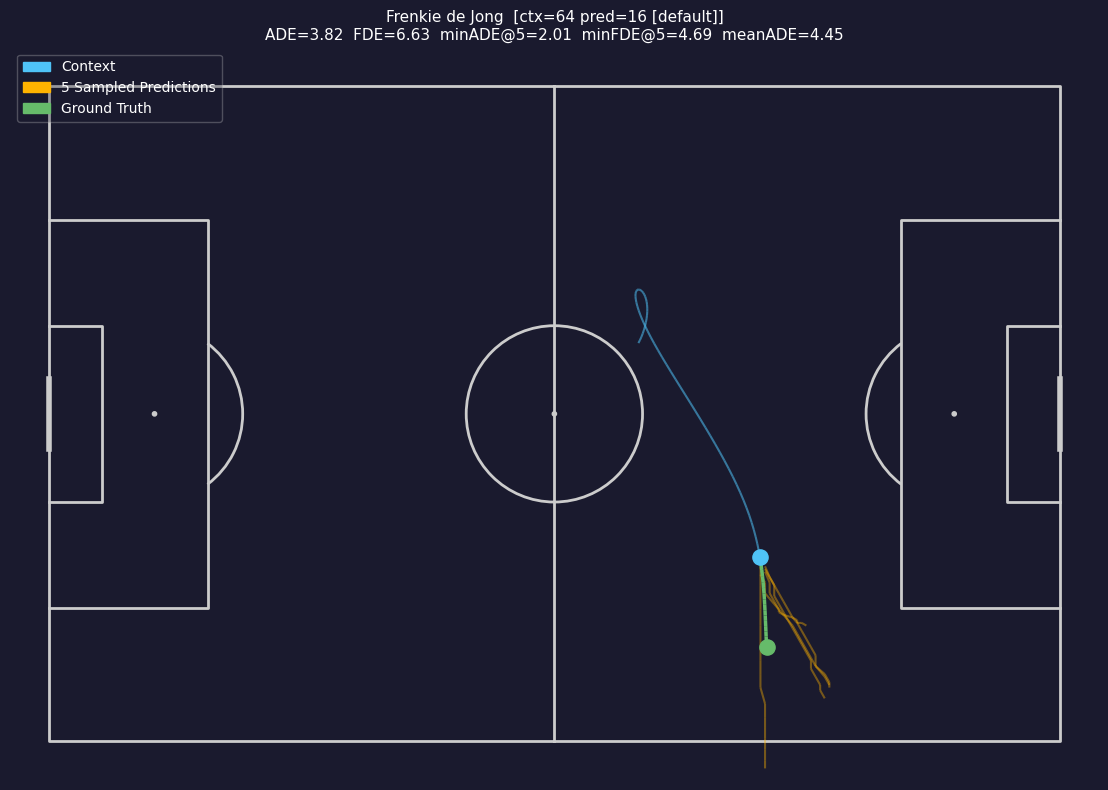

In [ ]:
# ── 6. Pitch visualisation (context | K preds | GT) ─────────

def visualize(df, player, context_len=64, pred_len=16, K=5, title_suffix=""):
    pdf    = df[df.player == player].reset_index(drop=True)
    coords = pdf[['x', 'y']].values
    split  = len(coords) - pred_len
    ctx    = coords[max(0, split - context_len): split]
    gt     = coords[split: split + pred_len]
    preds  = chronos_predict(ctx[:, 0], ctx[:, 1], pred_len, K)
    m      = compute_metrics(preds, gt)

    pitch = Pitch(pitch_type='custom', pitch_length=PITCH_LEN, pitch_width=PITCH_WID,
                  pitch_color='#1a1a2e', line_color='#cccccc')
    fig, ax = pitch.draw(figsize=(12, 8))
    fig.set_facecolor('#1a1a2e')

    # context
    for i in range(len(ctx) - 1):
        pitch.lines(ctx[i,0], ctx[i,1], ctx[i+1,0], ctx[i+1,1],
                    ax=ax, color='#4fc3f7', alpha=0.55, lw=1.5)

    # K sampled predictions
    for k in range(K):
        p = preds[k]
        for i in range(len(p) - 1):
            pitch.lines(p[i,0], p[i,1], p[i+1,0], p[i+1,1],
                        ax=ax, color='#ffb300', alpha=0.4, lw=1.5)

    # ground truth
    for i in range(len(gt) - 1):
        pitch.lines(gt[i,0], gt[i,1], gt[i+1,0], gt[i+1,1],
                    ax=ax, color='#66bb6a', lw=2.5)

    pitch.scatter(ctx[-1,0], ctx[-1,1], ax=ax, c='#4fc3f7', s=120, zorder=5)
    pitch.scatter(gt[-1,0],  gt[-1,1],  ax=ax, c='#66bb6a',  s=120, zorder=5)

    ax.set_title(
        f"{player}  [{title_suffix}]\n"
        f"ADE={m['ADE']:.2f}  FDE={m['FDE']:.2f}  "
        f"minADE@{K}={m['minADE']:.2f}  minFDE@{K}={m['minFDE']:.2f}  "
        f"meanADE={m['meanADE']:.2f}",
        color='white', fontsize=11,
    )
    ax.legend(
        handles=[
            Patch(color='#4fc3f7', label='Context'),
            Patch(color='#ffb300', label=f'{K} Sampled Predictions'),
            Patch(color='#66bb6a', label='Ground Truth'),
        ],
        loc='upper left', framealpha=0.3, labelcolor='white', facecolor='#1a1a2e',
    )
    plt.tight_layout()
    plt.show()


top_player = df.player.value_counts().index[1]
print(f"Visualising: {top_player}")
visualize(df, top_player, DEFAULT_CTX, DEFAULT_PRED, K,
          title_suffix=f"ctx={DEFAULT_CTX} pred={DEFAULT_PRED} [default]")

In [ ]:
# ── 7. Optuna — tune context_len & pred_len ──────────────────
# @ ~5 fps:  ctx=32→6.4s, ctx=64→12.8s, ctx=128→25.6s, ctx=256→51.2s
#            pred=8→1.6s,  pred=16→3.2s,  pred=32→6.4s
tune_players = df.player.value_counts().head(6).index.tolist()
df_tune      = df[df.player.isin(tune_players)]

def objective(trial):
    ctx  = trial.suggest_categorical('context_len', [32, 64, 128, 256])
    pred = trial.suggest_categorical('pred_len',    [8,  16, 32])
    r = evaluate(df_tune, ctx, pred, n_splits=2, K=K, min_events=50)
    return float(r['minADE'].mean()) if not r.empty else float('inf')

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=12, show_progress_bar=True)

BP = study.best_params
print(f"\nBest: context_len={BP['context_len']}, pred_len={BP['pred_len']}")
print(f"Best minADE: {study.best_value:.3f}")

  0%|          | 0/12 [00:00<?, ?it/s]


Best: context_len=256, pred_len=8
Best minADE: 0.596


Evaluating tuned params: context=256, pred=8 ...

=== Metrics Comparison ===
         Default (ctx=64/pred=16)  Tuned   (ctx=256/pred=8)
ADE                         2.076                     0.854
FDE                         4.517                     1.506
minADE                      1.304                     0.523
minFDE                      2.654                     0.855
meanADE                     2.497                     1.093
meanFDE                     5.355                     1.901


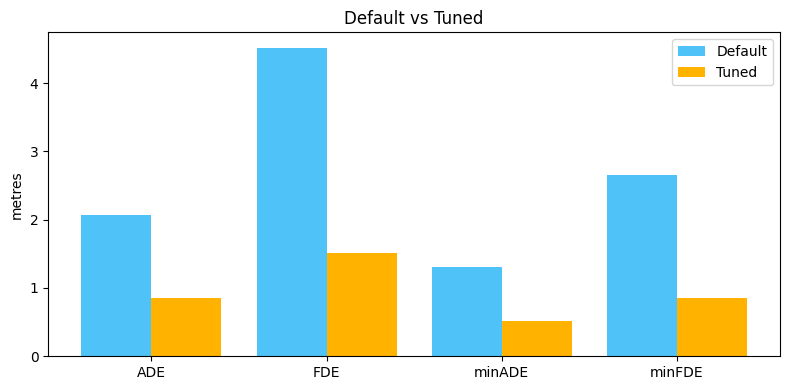

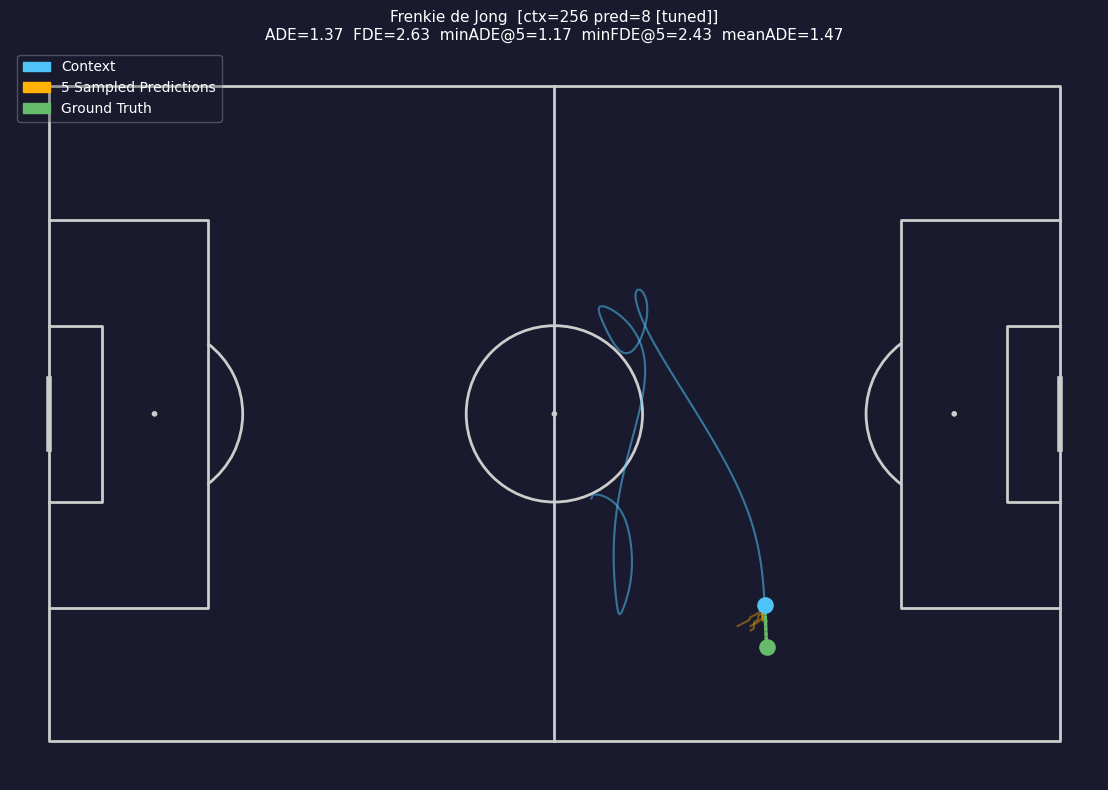

In [ ]:
# ── 8. Compare default vs tuned + re-visualise ───────────────
print(f"Evaluating tuned params: context={BP['context_len']}, pred={BP['pred_len']} ...")
res1  = evaluate(df, BP['context_len'], BP['pred_len'], K=K)
mean1 = res1[['ADE','FDE','minADE','minFDE','meanADE','meanFDE']].mean()

cmp = pd.DataFrame({
    f"Default (ctx={DEFAULT_CTX}/pred={DEFAULT_PRED})": mean0,
    f"Tuned   (ctx={BP['context_len']}/pred={BP['pred_len']})": mean1,
})
print("\n=== Metrics Comparison ===")
print(cmp.round(3))

# bar chart
metrics_to_plot = ['ADE', 'FDE', 'minADE', 'minFDE']
x = np.arange(len(metrics_to_plot))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, [mean0[m] for m in metrics_to_plot], 0.4,
       label='Default', color='#4fc3f7')
ax.bar(x + 0.2, [mean1[m] for m in metrics_to_plot], 0.4,
       label='Tuned',   color='#ffb300')
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot)
ax.set_ylabel('metres'); ax.set_title('Default vs Tuned')
ax.legend(); plt.tight_layout(); plt.show()

# re-visualise with best params
visualize(df, top_player, BP['context_len'], BP['pred_len'], K,
          title_suffix=f"ctx={BP['context_len']} pred={BP['pred_len']} [tuned]")